**BASE TASK**

**IMPORT STATEMENTS**

To load all tools/libraries
needed for the project

This cell imports all required libraries. Torch provides deep learning functionality, nn contains neural network components, DataLoader creates batches, datasets loads FashionMNIST, ToTensor converts images into tensors, matplotlib is used for visualization, and pickle helps save the trained model.

In [ ]:
import torch                                    #for deep learning(Ai toolbox)
from torch import nn                            #neural network
from torch.utils.data import DataLoader         #to create batches
from torchvision import datasets                #datasets(FashionMNIST)
from torchvision.transforms import ToTensor     #picture to number for training

import matplotlib.pyplot as plt                 #drawing tool
import pandas as pd
import pickle                                   #to save model

**LOAD FASHION-MNIST DATASET**

To download and load FashionMNIST dataset

This cell loads FashionMNIST dataset. To create separate training and testing datasets. The training dataset with 60,000 images is used for learning, while the testing dataset with 10,000 images is used for evaluation. The ToTensor transform converts images into tensors so the neural network can process them,that is,AI readable form


In [ ]:
#To load training dataset
train_data = datasets.FashionMNIST(
    root="data",                                                #images stored in folder named data
    train=True,                                                 #to get training images
    download=True,                                              #To download automatically from internet
    transform=ToTensor()                                        #convert images to  numbers
)

#To load testing dataset
test_data = datasets.FashionMNIST(
    root="data",
    train=False,                                                #to testing testing images
    download=True,
    transform=ToTensor()
)

**DATALOADER**

Converts dataset into batches

The DataLoader converts the dataset into manageable batches. The images are packed into 64 images per batch. Training data is shuffled to improve learning, while test data is kept unshuffled since it is only used for evaluation

In [ ]:
batch_size = 64

#To create batches for "training" images
train_loader = DataLoader(
    train_data,                                                 #Images for training AI
    batch_size=batch_size,
    shuffle=True                                                #to mix images randomly after every epoch for better unbiased learning
)
#To create batches for "testing" images
test_loader = DataLoader(
    test_data,                                                  #Images for testing AI
    batch_size=batch_size,
    shuffle=False                                               #For training the order is fixed
)

**DISPLAY IMAGES**

To show sample images from FashionMNIST in order to inspect data before training AI- DATA INSPECTION

"This cell displays sample FashionMNIST images with their labels. It helps verify that images and labels are loading correctly and allows us to understand the dataset before training the neural network.


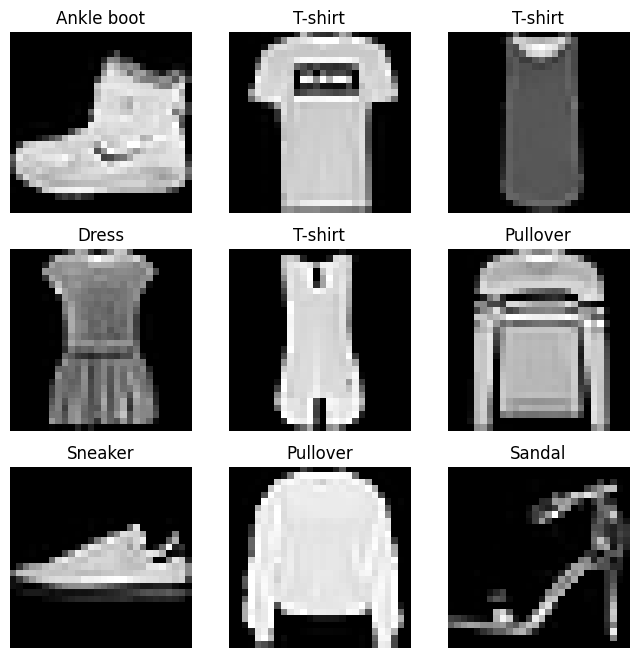

In [ ]:
labels = {                                           #Dictionary for storing image name and labels
    0: "T-shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

plt.figure(figsize=(8,8))                            #To create a drawing canva for plotting/showing image

for i in range(9):                                   #9 samples for data inspection

    image, label = train_data[i]

    plt.subplot(3,3,i+1)                             #To create a 3x3 grid with image occupying i+1 space|eg, for i=3 space occupied is 4
    plt.imshow(image.squeeze(), cmap="gray")         #To show image and squeeze it to remove extra graycale channel|obtained in grayscale map
    plt.title(labels[label])                         #To show image name above the image
    plt.axis("off")                                  #To hide axis for a clear image

plt.show()                                           #To finally show everything

**CONSTRUCTION OF NEURAL NETWORK**

To create the AI brain

Have contructed a feedforward neural network using PyTorch. The image is flattened from 28×28 into 784 pixels, passed through two hidden layers with ReLU activation, and finally produces 10 output scores corresponding to the FashionMNIST classes."

ReLU function: is like a decision gate and helps neuron detect strong patterns and reject weak signals

#Flowchart
image

↓

flatten

↓

784 pixels

↓

128 neurons

↓

ReLU

↓

64 neurons

↓

ReLU

↓

10 scores

In [ ]:
# Blueprint of AI model
class NeuralNetwork(nn.Module):                                    #To make model uing Pytorch Template

    # To construct the AI Brain (It's components)
    def __init__(self):

        super().__init__()                                         #Initializes Python Base module

        self.flatten = nn.Flatten()                                #Flattens: 28x28 to 784

        self.layer1 = nn.Linear(784,128)                           #Hidden layer1: 784 to 128
        self.relu1 = nn.ReLU()                                     #Activation function - Decision gate

        self.layer2 = nn.Linear(128,64)                            #Hidden layer2: 128 to 64
        self.relu2 = nn.ReLU()                                     #Activation function - Decision gate

        self.layer3 = nn.Linear(64,10)                             #Output layer: 10 classes

    #Forward propagation
    def forward(self,x):

        x = self.flatten(x)                                        #Flatten

        x = self.layer1(x)                                         #Hidden layer1
        x = self.relu1(x)

        x = self.layer2(x)                                         #Hidden layer2
        x = self.relu2(x)

        x = self.layer3(x)                                         #Output layer

        return x                                                   #Final scores for prediction

#Real AI model
model = NeuralNetwork()

print(model)                                                       #To show architecture of model

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=64, out_features=10, bias=True)
)


**LOSS FUNCTION and OPTIMIZER**

CrossEntropyLoss measures prediction error for classification problems, while SGD optimizer updates model weights using gradients to reduce the loss and improve prediction accuracy

SGD-Stochastic Gradient Descent-use gradients to update weights and reduce losses

lr-Learning Rate-size of weight update

Moderate step size of 0.01 is chosen so that learning process is stable

In [ ]:
#To Calculate Loss
loss_function = nn.CrossEntropyLoss()                                            #Loss calculator

#To update weights for AI learning
optimizer = torch.optim.SGD(                                                     #Optimizer
    model.parameters(),                                                          #To update weights in all layers
    lr=0.01                                                                      #Learning rate
)

**Train the AI Brain**

This training function processes batches of images, generates predictions, computes CrossEntropy loss, clears previous gradients, performs backpropagation, updates model weights using SGD, and finally calculates average loss and accuracy for the epoch

Aim is to reduce the loss and increase accuracy after every epoch

In [ ]:
def train_model():                                                        #Function for training brain

    model.train()                                                         #Activates training mode

    total_loss = 0
    total_correct = 0
    total_images = 0

    for images, labels in train_loader:                                   #train_loader consists of batches of images
        predictions = model(images)                                       #Gives the 10 output scores for 64 images

        loss = loss_function(                                             #To calculate loss (tensor)
            predictions,
            labels
        )

        optimizer.zero_grad()                                             #To elimiante the old gradients

        loss.backward()                                                   #Backward propagation | suitable gradients are decided

        optimizer.step()                                                  #updation of weights for actual learning

        total_loss += loss.item()                                         #total loss is calculated and tensor is converted to number

        predicted_labels = predictions.argmax(1)                          #Gives the index of highest score output for 64 images

        correct_predictions = (                                           #To check if prediction is correct or not
            predicted_labels == labels
        ).sum().item()                                                    #To sum up for 64 images and convert the tensor to numbers

        total_correct += correct_predictions                              #To calculate total correct predictions

        total_images += labels.size(0)                                    #To calculate total no. of images

    #Average loss
    average_loss = total_loss / len(train_loader)

    #Accuracy
    accuracy = (
        total_correct / total_images
    ) * 100

    return average_loss, accuracy

**TEST FUNCTION**

The testing function evaluates the model on unseen data using eval mode and no_grad to disable gradient calculations. It computes prediction loss and accuracy without updating weights (no learning)

In [ ]:
def test_model():                                                          #Testing function

    model.eval()                                                           #Activates testing mode

    total_loss = 0
    total_correct = 0
    total_images = 0

    with torch.no_grad():                                                  #Disables gradient calculations to avoid accident learning

        for images, labels in test_loader:

            predictions = model(images)                                    #Gives the 10 output scores for 64 images

            loss = loss_function(                                          #To calculate loss (tensor)
                predictions,
                labels
            )

            total_loss += loss.item()                                      #total loss is calculated and tensor is converted to number

            predicted_labels = predictions.argmax(1)                       #Gives the index of highest score output for 64 images

            correct_predictions = (                                        #To check if prediction is correct or not
                predicted_labels == labels
            ).sum().item()

            total_correct += correct_predictions                           #To calculate total correct predictions

            total_images += labels.size(0)                                 #To calculate total no. of images


    #Average loss
    average_loss = total_loss / len(test_loader)

    #Accuracy
    accuracy = (
        total_correct / total_images
    ) * 100

    return average_loss, accuracy

**ACTUAL TRAINING LOOP**

The model showed decreasing loss and increasing training and testing accuracy across epochs, indicating successful learning. Final test accuracy reached around 82%, showing good generalization on unseen FashionMNIST images

No case of overfitting is observed here as training and testing accuracy are improving after each epoch

As we have just used neural network a final test accuracy of 82% approx from 66% is respectable

The ouput clearly shows that weights have been properly updated after training and the learning process has been successfully completed

Epoch is greater than 1, so that weights can be further improved with a greater number of rounds. It is limited to 5 in order to ensure that overfitting doesn't take place

In [ ]:
epochs = 5
train_accuracies=[]
train_losses=[]
test_accuracies=[]
test_losses=[]

for epoch in range(epochs):

    print("Epoch", epoch + 1)

    train_loss, train_accuracy = train_model()

    test_loss, test_accuracy = test_model()

    print("Training Loss:", train_loss)
    print("Training Accuracy:", train_accuracy)

    print("Test Loss:", test_loss)
    print("Test Accuracy:", test_accuracy)

    print("-------------------")
    train_accuracies.append(train_accuracy)
    train_losses.append(train_loss)
    test_accuracies.append(test_accuracy)
    test_losses.append(test_loss)

Epoch 1
Training Loss: 1.443800353292209
Training Accuracy: 51.27166666666667
Test Loss: 0.876430124234242
Test Accuracy: 66.44
-------------------
Epoch 2
Training Loss: 0.754360313068575
Training Accuracy: 72.465
Test Loss: 0.7291452174733399
Test Accuracy: 71.78
-------------------
Epoch 3
Training Loss: 0.6201102446391384
Training Accuracy: 78.16499999999999
Test Loss: 0.608409840969523
Test Accuracy: 77.85
-------------------
Epoch 4
Training Loss: 0.5506581507766171
Training Accuracy: 80.875
Test Loss: 0.5476210665930609
Test Accuracy: 80.71000000000001
-------------------
Epoch 5
Training Loss: 0.5101844717476414
Training Accuracy: 82.16499999999999
Test Loss: 0.5355988497946672
Test Accuracy: 80.34
-------------------


**TO SAVE TRAINED MODEL**

Pickle was used to serialize and save the trained model weights stored in state_dict into a .pkl file for reuse

state_dict() creates a dictionary storing the learned weights and biases for every layer of the ai model

File name is fashion_model and pkl is Pickle extension

In [ ]:
import pickle                                                              #Python saving object

with open("fashion_model.pkl", "wb") as file:                              #creates a binary file

    pickle.dump(                                                           #loads the trained weights into this file
        model.state_dict(),
        file
    )

print("Pickle Model Saved Successfully!")

Pickle Model Saved Successfully!


**LOAD SAVED MODEL and MAKE PREDICTIONS**

A new model object is created and the saved pickle weights are loaded into state_dict, restoring the trained network for prediction

In [ ]:
loaded_model = NeuralNetwork()                                            #new empty brain

import pickle

with open("fashion_model.pkl", "rb") as file:                             #To read the trained weights

    saved_weights = pickle.load(file)                                     #To extract trained weights

loaded_model.load_state_dict(                                             #Put trained weights into empty brain
    saved_weights
)

loaded_model.eval()                                                       #Activates testing mode

print("Pickle Model Loaded Successfully!")

Pickle Model Loaded Successfully!


**FINAL PREDICTION and IMAGE DISPLAY**

A test image is taken and reshaped into a batch using unsqueeze. The trained model predicts class scores, argmax selects the highest-scoring class, and the predicted index is converted into a clothing label using a dictionary

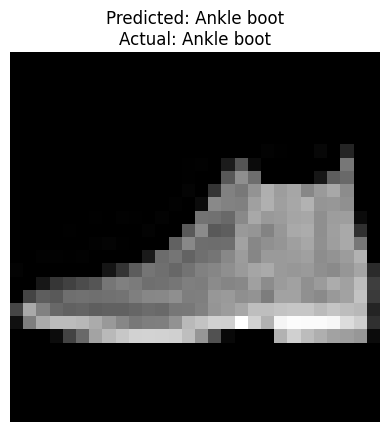

Predicted: Ankle boot
Actual: Ankle boot


In [ ]:
labels_map = {                                                              #Dictionary for storing image name and labels
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

image, true_label = test_data[0]                                            #take the first iamge

image_batch = image.unsqueeze(0)                                            #To add the extra dimension to make image batches

with torch.no_grad():                                                       #To eliminate gradient calculation

    prediction = loaded_model(image_batch)                                  #Gives 10 output scores

predicted_label = prediction.argmax(1).item()                               #index of highest output score and converts tensor to number

#To display the image
plt.imshow(
    image.squeeze(),                                                        #To remove extra channel dimension
    cmap="gray"                                                             #To show image in grayscale
)

plt.title(
    "Predicted: " +
    labels_map[predicted_label]
    +
    "\nActual: " +
    labels_map[true_label]
)

plt.axis("off")                                                             #To hide axis

plt.show()

#AI prediction
print(
    "Predicted:",
    labels_map[predicted_label]
)

#Actual clothing type
print(
    "Actual:",
    labels_map[true_label]
)

plt.show()                                                                  #To finally show everything

**LOSS and ACCURACY GRAPH vs Epoch**

Graphs help visualize model learning behaviour across epochs. Loss graphs show whether error decreases, while accuracy graphs show whether prediction performance improves and help detect overfitting.

Here the loss graph decreases and the accuracy graph increases

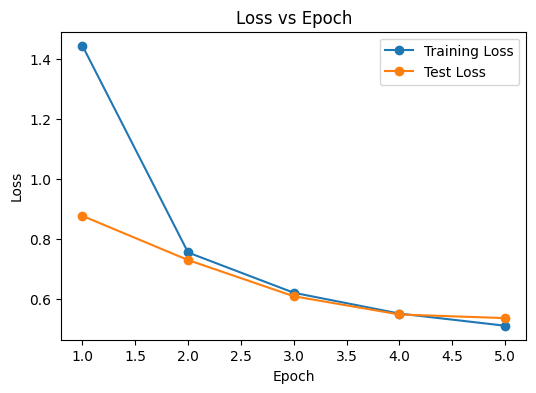

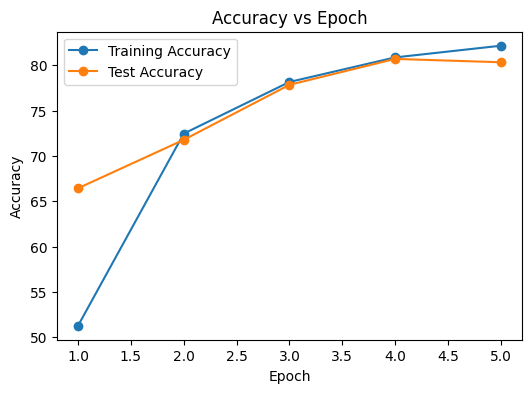

In [ ]:
import matplotlib.pyplot as plt                                           #drawing tool

epochs_range = [1, 2, 3, 4, 5]                                            #X-Axis


plt.figure(figsize=(6,4))                                                 #creates graph canva of required size

#To plot training and test losses againt epoch
plt.plot(epochs_range, train_losses, marker='o')
plt.plot(epochs_range, test_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend(["Training Loss", "Test Loss"])
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_accuracies, marker='o')
plt.plot(epochs_range, test_accuracies, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend(["Training Accuracy", "Test Accuracy"])
plt.show()

**CREATE submission.csv**

The trained model was used in evaluation mode to predict labels for all test batches. Predictions were collected into a list, converted into a pandas DataFrame, and saved as submission.csv using to_csv

In [ ]:
import pandas as pd                                                 #Tool to crete tables and spreadsheets

predictions_list = []                                               #list to store ai predicted labels

loaded_model.eval()                                                 #Activates testing mode

with torch.no_grad():                                               #eliminates gradient calculation

    for images, labels in test_loader:

        outputs = loaded_model(images)                              #Gives 10 output scores for 64 images

        predicted = outputs.argmax(1)                               #index of highest output score

        predictions_list.extend(
            predicted.tolist()                                      #To add predicted labels to list and tolist is used to convert tensor to number
        )

submission = pd.DataFrame({                                         #To create table
    "Id": range(len(predictions_list)),
    "Prediction": predictions_list
})

#To save table as csv file
submission.to_csv(
    "submission.csv",                                              #file name
    index=False                                                    #To remove index,that is, extra column
)

print("submission.csv created successfully!")

submission.csv created successfully!


**RESEARCH DOMAIN-Label Smoothing Experiments**

**Creating loss function with Label smoothing**

To create a smoothed loss function which converts the hard labels to soft labels

In [ ]:
#New loss function
smooth_loss_function = nn.CrossEntropyLoss(label_smoothing=0.1)                    #label smoothing factor is set to 10%

print("Label Smoothing Loss Created!")

Label Smoothing Loss Created!


**CREATE MODEL WITH LABEL SMOOTHING**

To create a new model for label smoothing in order to compare this with the normal model

In [ ]:
smooth_model = NeuralNetwork()                                              #Creates a new model with random weights but with same architecture

optimizer_smooth = torch.optim.Adam(smooth_model.parameters(), lr=0.001)    #To create the optimizer for the new model with same learning rate

print(smooth_model)



NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=64, out_features=10, bias=True)
)


**Training and Testing of Model**

This cell trains and evaluates a separate neural network using Label Smoothing CrossEntropy loss. It follows the same architecture, optimizer, epochs and data pipeline as the Base Task, ensuring a controlled experiment. During training, the model performs forward propagation, computes smoothed loss, performs backpropagation and updates weights. After each epoch, testing is performed without gradient calculation to monitor generalization. Training and testing metrics are stored for later comparison and graph analysis against the normal model.

The gap between training and testing accuracy is small which proves the fact that label smoothing reduces overfitting

In [ ]:
# Training Label Smoothing Model

smooth_train_loss = []
smooth_test_loss = []
smooth_train_acc = []
smooth_test_acc = []

epochs = 5

for epoch in range(epochs):

    # Training
    smooth_model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        optimizer_smooth.zero_grad()

        outputs = smooth_model(images)

        loss = smooth_loss_function(outputs, labels)

        loss.backward()

        optimizer_smooth.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    smooth_train_loss.append(train_loss)
    smooth_train_acc.append(train_accuracy)

    # Testing
    smooth_model.eval()

    test_running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            outputs = smooth_model(images)

            loss = smooth_loss_function(outputs, labels)

            test_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    test_loss = test_running_loss / len(test_loader)
    test_accuracy = 100 * correct / total

    smooth_test_loss.append(test_loss)
    smooth_test_acc.append(test_accuracy)

    print("Epoch", epoch + 1)
    print("Training Loss:", train_loss)
    print("Training Accuracy:", train_accuracy)
    print("Test Loss:", test_loss)
    print("Test Accuracy:", test_accuracy)
    print("-------------------")

Epoch 1
Training Loss: 0.9612944105794943
Training Accuracy: 81.065
Test Loss: 0.8777664842878937
Test Accuracy: 84.42
-------------------
Epoch 2
Training Loss: 0.8247105808400396
Training Accuracy: 86.27666666666667
Test Loss: 0.8310000402912213
Test Accuracy: 85.63
-------------------
Epoch 3
Training Loss: 0.7842592736805426
Training Accuracy: 87.90333333333334
Test Loss: 0.8040101239635686
Test Accuracy: 87.06
-------------------
Epoch 4
Training Loss: 0.7622868397088447
Training Accuracy: 88.735
Test Loss: 0.7881636323442884
Test Accuracy: 87.6
-------------------
Epoch 5
Training Loss: 0.7444397273983783
Training Accuracy: 89.38833333333334
Test Loss: 0.7764024996453789
Test Accuracy: 87.84
-------------------


**EXPERIMENT-1**

**Normal Training vs Label Smoothing**

The training and test accuracies for label smoothened model is greater than that of normal model proving the better performace and learning of label smoothened model

With experimental results the reserach statementof label smoothing increasing performance and making training more gentler is validated

In [ ]:
# Comparing Final Results

print("NORMAL MODEL RESULTS")
print("Training Accuracy:", train_accuracies[-1])
print("Test Accuracy:", test_accuracies[-1])

print("-------------------")

print("LABEL SMOOTHING RESULTS")
print("Training Accuracy:", smooth_train_acc[-1])
print("Test Accuracy:", smooth_test_acc[-1])

NORMAL MODEL RESULTS
Training Accuracy: 82.16499999999999
Test Accuracy: 80.34
-------------------
LABEL SMOOTHING RESULTS
Training Accuracy: 89.38833333333334
Test Accuracy: 87.84


**Comparision Graph**

I plotted test accuracy across epochs for both models to visually compare their learning behaviour and generalization. While final accuracy is important, the graph helps analyze stability, convergence and performance trends during training.

It is clear from the graph that due to softer targets,better learning and less overconfidence, label smoothing model has performed better than normal model

This increase in test accuracy further reduces overfitting and improves generalization

These results are a good validation to the reserach paper's statement

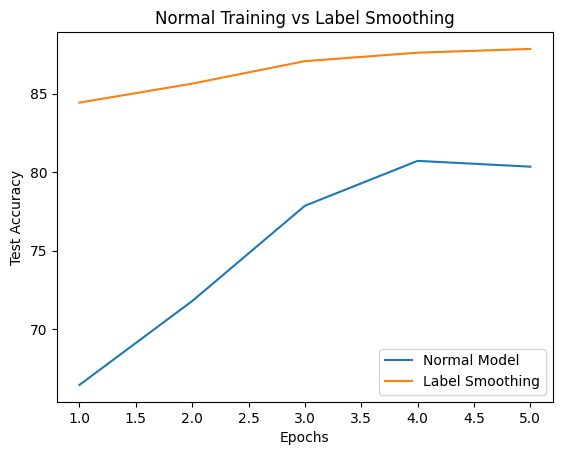

In [ ]:
# Accuracy Comparison Graph

plt.plot(epochs_range, test_accuracies, label="Normal Model")                  #Normal Model test accuarcy grpah

plt.plot(epochs_range, smooth_test_acc, label="Label Smoothing")               #Label Smoothing Model test accuracy graph

plt.title("Accuracy Comparison")

plt.xlabel("Epochs")
plt.ylabel("Test Accuracy")

plt.title("Normal Training vs Label Smoothing")

plt.legend()

plt.show()

**EXPERIMENT-2**

**Loss function for new smoothing factor**

Leads to more softening

In [ ]:
# Label Smoothing with epsilon = 0.2

smooth_loss_02 = nn.CrossEntropyLoss(label_smoothing=0.2)                     #Smoothness is increased to 20%

print("Label Smoothing 0.2 Created!")

Label Smoothing 0.2 Created!


**Creating Model for epsilon=0.2**

To create new model for increased softness so that experimnet is fair

In [ ]:
# Creating Model for epsilon = 0.2

smooth_model_02 = NeuralNetwork()                                             #New model

optimizer_smooth_02 = torch.optim.Adam(                                       #New optimizer with same learning rate
    smooth_model_02.parameters(),
    lr=0.001
)

print(smooth_model_02)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=64, out_features=10, bias=True)
)


**Training and Testing of more smoothened model**

To train and test model with stronger softening

In [ ]:
# Training epsilon = 0.2 model

smooth02_train_loss = []
smooth02_test_loss = []
smooth02_train_acc = []
smooth02_test_acc = []

epochs = 5

for epoch in range(epochs):

    # Training
    smooth_model_02.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        optimizer_smooth_02.zero_grad()

        outputs = smooth_model_02(images)

        loss = smooth_loss_02(outputs, labels)

        loss.backward()

        optimizer_smooth_02.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    smooth02_train_loss.append(train_loss)
    smooth02_train_acc.append(train_accuracy)

    # Testing
    smooth_model_02.eval()

    test_running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            outputs = smooth_model_02(images)

            loss = smooth_loss_02(outputs, labels)

            test_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    test_loss = test_running_loss / len(test_loader)
    test_accuracy = 100 * correct / total

    smooth02_test_loss.append(test_loss)
    smooth02_test_acc.append(test_accuracy)

    print("Epoch", epoch + 1)
    print("Training Loss:", train_loss)
    print("Training Accuracy:", train_accuracy)
    print("Test Loss:", test_loss)
    print("Test Accuracy:", test_accuracy)
    print("-------------------")

Epoch 1
Training Loss: 1.251323545538286
Training Accuracy: 80.90333333333334
Test Loss: 1.179799508896603
Test Accuracy: 83.8
-------------------
Epoch 2
Training Loss: 1.131219560149382
Training Accuracy: 86.49666666666667
Test Loss: 1.1482991678699566
Test Accuracy: 85.83
-------------------
Epoch 3
Training Loss: 1.0984063559630786
Training Accuracy: 87.92333333333333
Test Loss: 1.1128909341089286
Test Accuracy: 86.74
-------------------
Epoch 4
Training Loss: 1.078991189249543
Training Accuracy: 88.70666666666666
Test Loss: 1.105777913977386
Test Accuracy: 87.12
-------------------
Epoch 5
Training Loss: 1.0670482342177108
Training Accuracy: 89.31
Test Loss: 1.097000455021099
Test Accuracy: 87.67
-------------------


**Final numerical results**

We can observe that accuracy increases on shifting from normal to epsilon=0.1 whereas it shows a little fluctuation as we move from epsilon=0.1 to epsilon=0.2

This proves that stronger softening can hurt performance mentioned in the research paper

So a balanced epsilon value is required to reduce overconfidence and improve learning

In [ ]:
# Final Accuracy Comparison

print("NORMAL MODEL (epsilon = 0.0)")                                   #normal model
print("Training Accuracy:", train_accuracies[-1])
print("Test Accuracy:", test_accuracies[-1])

print("-------------------")

print("LABEL SMOOTHING (epsilon = 0.1)")                                #epsilon=0.1
print("Training Accuracy:", smooth_train_acc[-1])
print("Test Accuracy:", smooth_test_acc[-1])

print("-------------------")

print("LABEL SMOOTHING (epsilon = 0.2)")                                #epsilon=0.2
print("Training Accuracy:", smooth02_train_acc[-1])
print("Test Accuracy:", smooth02_test_acc[-1])

NORMAL MODEL (epsilon = 0.0)
Training Accuracy: 82.16499999999999
Test Accuracy: 80.34
-------------------
LABEL SMOOTHING (epsilon = 0.1)
Training Accuracy: 89.38833333333334
Test Accuracy: 87.84
-------------------
LABEL SMOOTHING (epsilon = 0.2)
Training Accuracy: 89.31
Test Accuracy: 87.67


**Comparision graphs**

The graph comparing different smoothing values showed that all models learned progressively over epochs. The normal model achieved the lowest performance, while Label Smoothing improved test accuracy significantly. Among the tested values, ε=0.1 achieved the highest accuracy, whereas ε=0.2 showed slightly lower performance. This indicates that moderate smoothing improved generalization, but excessive smoothing did not provide additional benefit.  

The graph had both increasing and decreasing plots for epsilon=0.2 proving it's instability

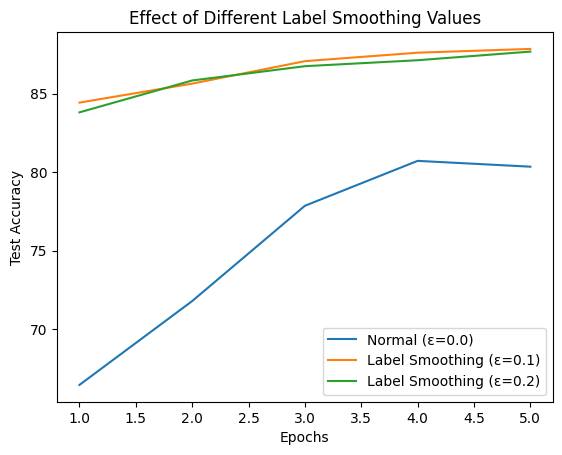

In [ ]:
# Epsilon Comparison Graph

plt.plot(epochs_range, test_accuracies, label="Normal (ε=0.0)")                       #normal model

plt.plot(epochs_range, smooth_test_acc, label="Label Smoothing (ε=0.1)")              #label smoothing model|epsilon=0.1

plt.plot(epochs_range, smooth02_test_acc, label="Label Smoothing (ε=0.2)")            #label smoothing model|epsilon=0.2

plt.xlabel("Epochs")
plt.ylabel("Test Accuracy")

plt.title("Effect of Different Label Smoothing Values")

plt.legend()

plt.show()

**EXPERIMNET-3-OVERFITTING AND GENERALIZATION**

**TRAIN vs TEST ACCURACY**

Normal model

Training accuracy alone can be misleading because a model may memorize training data. Comparing train and test curves helps evaluate overfitting and determine whether learning generalizes to unseen data.

Here the gap between test and train accuracy is small and hence we can conclude that the normal model itself has performed well on unseen data because of it's strong baseline

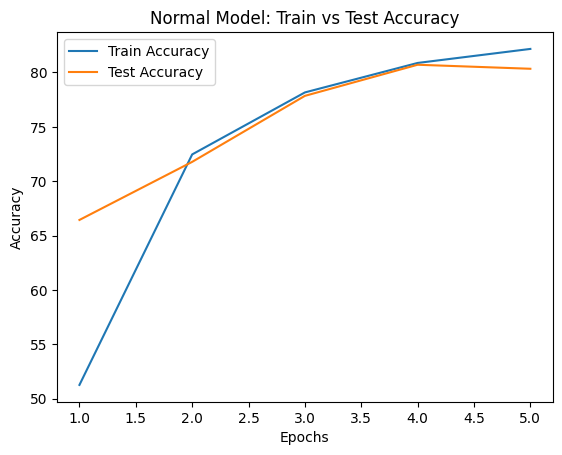

In [ ]:
# Overfitting Analysis - Normal Model

plt.plot(epochs_range, train_accuracies, label="Train Accuracy")                   #shows training of model

plt.plot(epochs_range, test_accuracies, label="Test Accuracy")                     #shows generalization

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.title("Normal Model: Train vs Test Accuracy")

plt.legend()

plt.show()

**Train vs Test Accuracy**

Label Smoothened Model

Here the gap was a little bit larger but had high test accuracy

Conclusion:

Although the label-smoothed model showed a slightly larger train–test gap than the normal model, the gap remained small and did not indicate severe overfitting. More importantly, label smoothing achieved substantially higher test accuracy and maintained stable generalization performance. Therefore, the experiments suggest that label smoothing improved predictive performance and generalization quality, even though it did not strictly minimize the train–test gap.

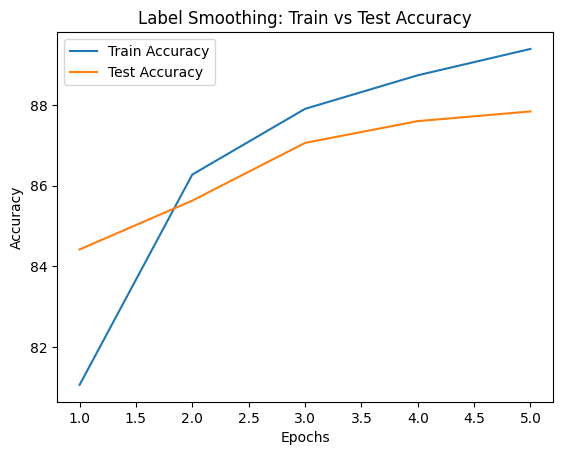

In [ ]:
# Overfitting Analysis - Label Smoothing

plt.plot(epochs_range, smooth_train_acc, label="Train Accuracy")

plt.plot(epochs_range, smooth_test_acc, label="Test Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.title("Label Smoothing: Train vs Test Accuracy")

plt.legend()

plt.show()

**EXPERIMENT-4-Confidence Calibration**

**Normal Model Confidence**

The confidence is very high,indicating that the model is too overconfident in  predicting this particular image

Hence the model is too certain and this might be risky sometimes when the images are not so clear

In [ ]:
# Prediction Confidence - Normal Model

image, true_label = test_data[2]                                               #one data

image_batch = image.unsqueeze(0)                                               #Add extra batch dimension

model.eval()                                                                   #Activates testing mode

with torch.no_grad():

    outputs = model(image_batch)                                               #Get prediction(logits)

    probabilities = torch.softmax(outputs, dim=1)                              #Convert logits to probabilities

    confidence, prediction = torch.max(probabilities, 1)                       #Get confidence and predicted class

print("True Label:", labels_map[true_label])

print("Predicted Label:", labels_map[prediction.item()])

print("Confidence:", confidence.item() * 100)

True Label: Trouser
Predicted Label: Trouser
Confidence: 99.97859597206116


**Smooth Model Confidence**

The confidence % is reduced and hence the experiment proves the statement  that label smoothening reduces overconfidence which in turn reduces overfitting and improves generalization

In [ ]:
# Prediction Confidence - Smoothened Model

image, true_label = test_data[2]                                               #one data

image_batch = image.unsqueeze(0)                                               #Add extra batch dimension

smooth_model.eval()                                                            #Activates testing mode

with torch.no_grad():

    outputs = smooth_model(image_batch)                                               #Get prediction(logits)

    probabilities = torch.softmax(outputs, dim=1)                              #Convert logits to probabilities

    confidence, prediction = torch.max(probabilities, 1)                       #Get confidence and predicted class

print("True Label:", labels_map[true_label])

print("Predicted Label:", labels_map[prediction.item()])

print("Confidence:", confidence.item() * 100)

True Label: Trouser
Predicted Label: Trouser
Confidence: 91.56373739242554


****